In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
DATA_PATH = 'survey_data.csv'

map_questions = {
    "The generated interface accurately reflects the specific application type and functional context (e.g., login, onboarding, e-commerce) defined in the prompt.": "Q1",
    "The generated UI effectively balances structural adherence to the sketch with creative design generation.": "Q2",
    "The key interface elements (CTAs and titles) stand out effectively within the visual hierarchy.": "Q3",
    "The overall UI aesthetics are professional and meet current industry standards.": "Q4",
    "The generated UI is technically feasible and could be implemented by a frontend developer without major restructuring.": "Q5",
    "The quality of the generated UI meets my professional expectations for an AI-assisted design tool.": "Q6",
}

response_map = {
    "Strongly Disagree": 1,
    "Disagree": 2,
    "Neutral": 3,
    "Agree": 4,
    "Strongly Agree": 5
}

colors = {
    1: '#C32314',  # Dark Red
    2: '#E6AAA0',  # Light Red/Orange
    3: '#E1E1E1',  # Light Gray
    4: '#78AFE6',  # Light Green
    5: '#236EC3'   # Dark Green
}

legend = ['Discordo fortemente', 'Discordo', 'Neutro', 'Concordo', 'Concordo fortemente']
def preprocess_survey_data():
    df = pd.read_csv(DATA_PATH)
    # Drop the first 5 columns  and the last column, those are not part of Likert evaluation
    df_questions = df.iloc[:, 5:-1].copy()
    df_questions = df_questions.replace(response_map)
    num_cols = df_questions.shape[1]
    samples_dfs = []
    num_questions = len(map_questions)
    for i in range(0, num_cols, num_questions):
        # Isolate the 6-column chunk
        chunk = df_questions.iloc[:, i:i+num_questions].copy()
        chunk.columns = chunk.columns.str.replace(r'\.\d+$', '', regex=True)
        chunk = chunk.rename(columns=map_questions)
        samples_dfs.append(chunk)
    return samples_dfs


In [8]:
categories = [1, 2, 3, 4, 5]
def plot_likert_diverging(sample_df, sample_id):
    # 1. Calculate Percentages
    counts = sample_df.apply(lambda x: x.value_counts()).fillna(0).T
    # Force all 5 columns to exist just in case a rating got 0 votes across the whole sample
    for i in range(1, 6):
        if i not in counts.columns:
            counts[i] = 0
            
    counts = counts[categories]
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100
    
    # 2. Chart Setup
    fig, ax = plt.subplots(figsize=(8, 4))
    
    # 4. Calculate Offsets (center on neutral 3)
    left_offset = -(percentages[1] + percentages[2] + percentages[3] / 2)
    
    # 5. Plot the Bars
    for val in categories:
        widths = percentages[val]
        ax.barh(
            percentages.index, 
            widths, 
            left=left_offset, 
            color=colors[val], 
            edgecolor='white', 
            height=0.8,
            label=f'Score {val}'
        )
        left_offset += widths  
        
    # 6. Formatting & Styling
    
    # Add a center reference line
    ax.axvline(0, color='gray', linewidth=1.5, linestyle='--')
    
    # Format X-axis
    formatter = FuncFormatter(lambda x, pos: f"{abs(x):.0f}%")
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel('Porcentagem de respostas')
    ax.set_xlim(-100, 100) 
    
    # --- STYLING ADJUSTMENTS ---
    
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Set left and bottom axes to 1.5px black
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['bottom'].set_color('black')
    
    # Create square legends
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles, 
        legend, 
        loc='upper center', 
        bbox_to_anchor=(0.5, -0.15), 
        ncol=5, 
        frameon=False,
        handlelength=1,   # Equal length and height make a square
        handleheight=1
    )
    
    # Invert Y-axis so Q1 is at the top
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig(f'sample_{sample_id}.tiff', format='tiff', bbox_inches='tight')
    plt.show()

/tmp/ipykernel_1267271/3645054781.py:33: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_questions = df_questions.replace(response_map)


Sample 1


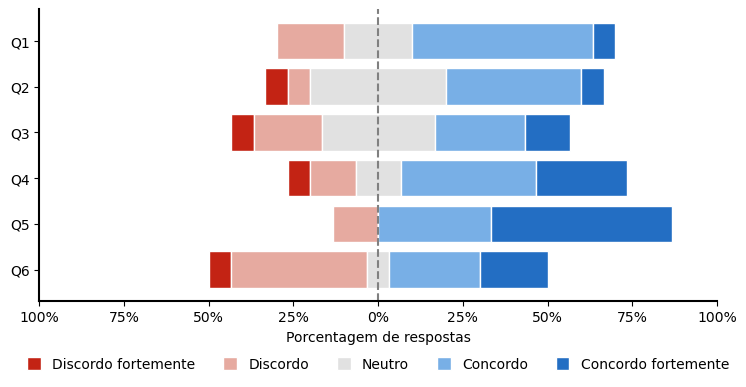

Sample 2


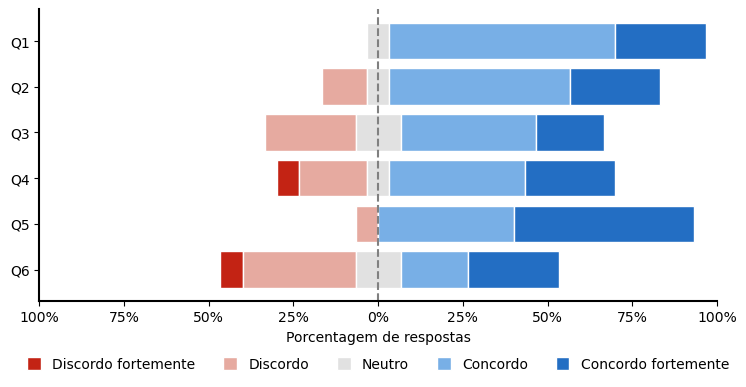

Sample 3


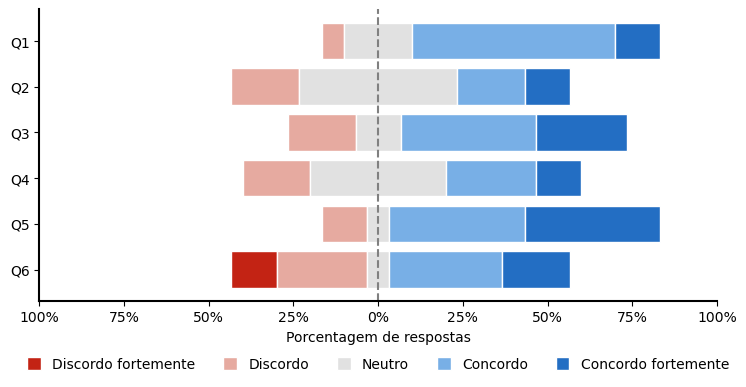

Sample 4


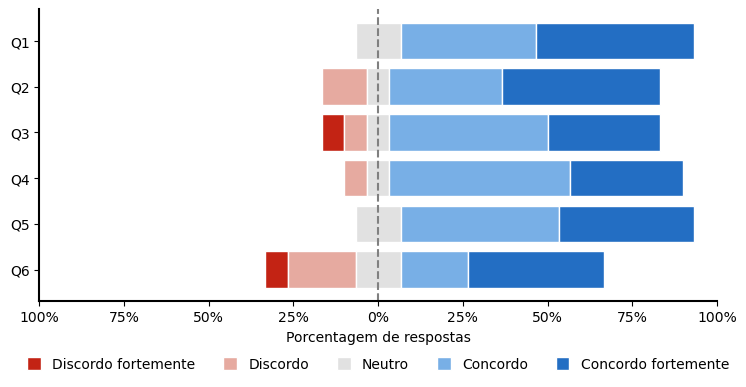

Sample 5


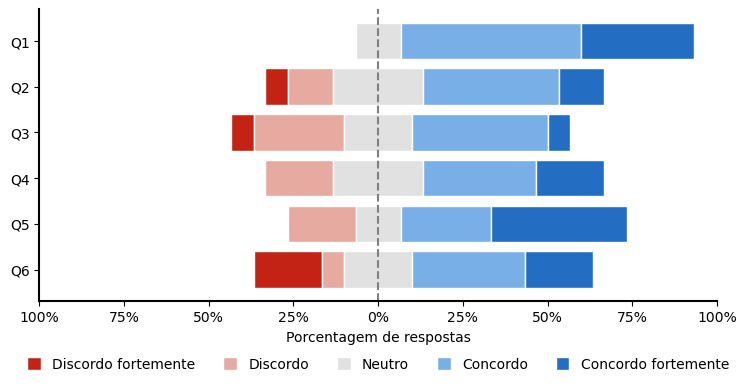

Sample 6


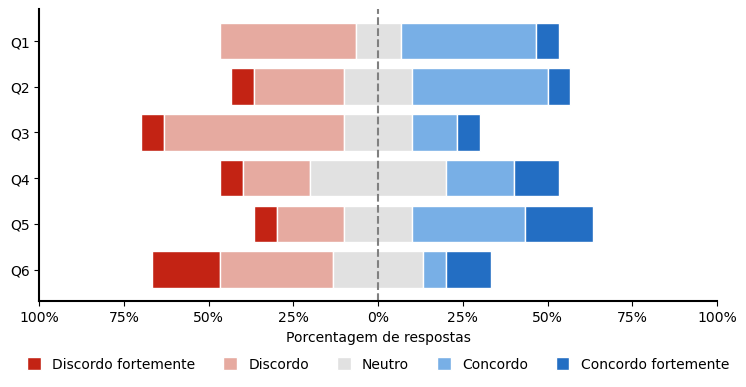

In [9]:
survey_data = preprocess_survey_data()

for i, sample_df in enumerate(survey_data):
    print(f'Sample {i+1}')
    plot_likert_diverging(sample_df, i+1)